In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [21]:
adults_data = pd.read_csv(r"C:\Users\gonts\Downloads\adult.csv.zip")
adults_data.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [33]:
adults_data.columns = adults_data.columns.str.strip().str.lower().str.replace(' ', '-')
adults_data.replace("?", pd.NA, inplace=True)
categorical_var = adults_data.select_dtypes(include=['object']).columns
for column in categorical_var:
    adults_data[column] = adults_data[column].fillna(adults_data[column].mode()[0])

numerical_var = adults_data.select_dtypes(include=['int64', 'float64']).columns
for column in numerical_var:
    adults_data[column] = adults_data[column].fillna(adults_data[column].median())
adults_data.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,Private,77053,HS-grad,9,Widowed,Prof-specialty,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,Private,186061,Some-college,10,Widowed,Prof-specialty,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


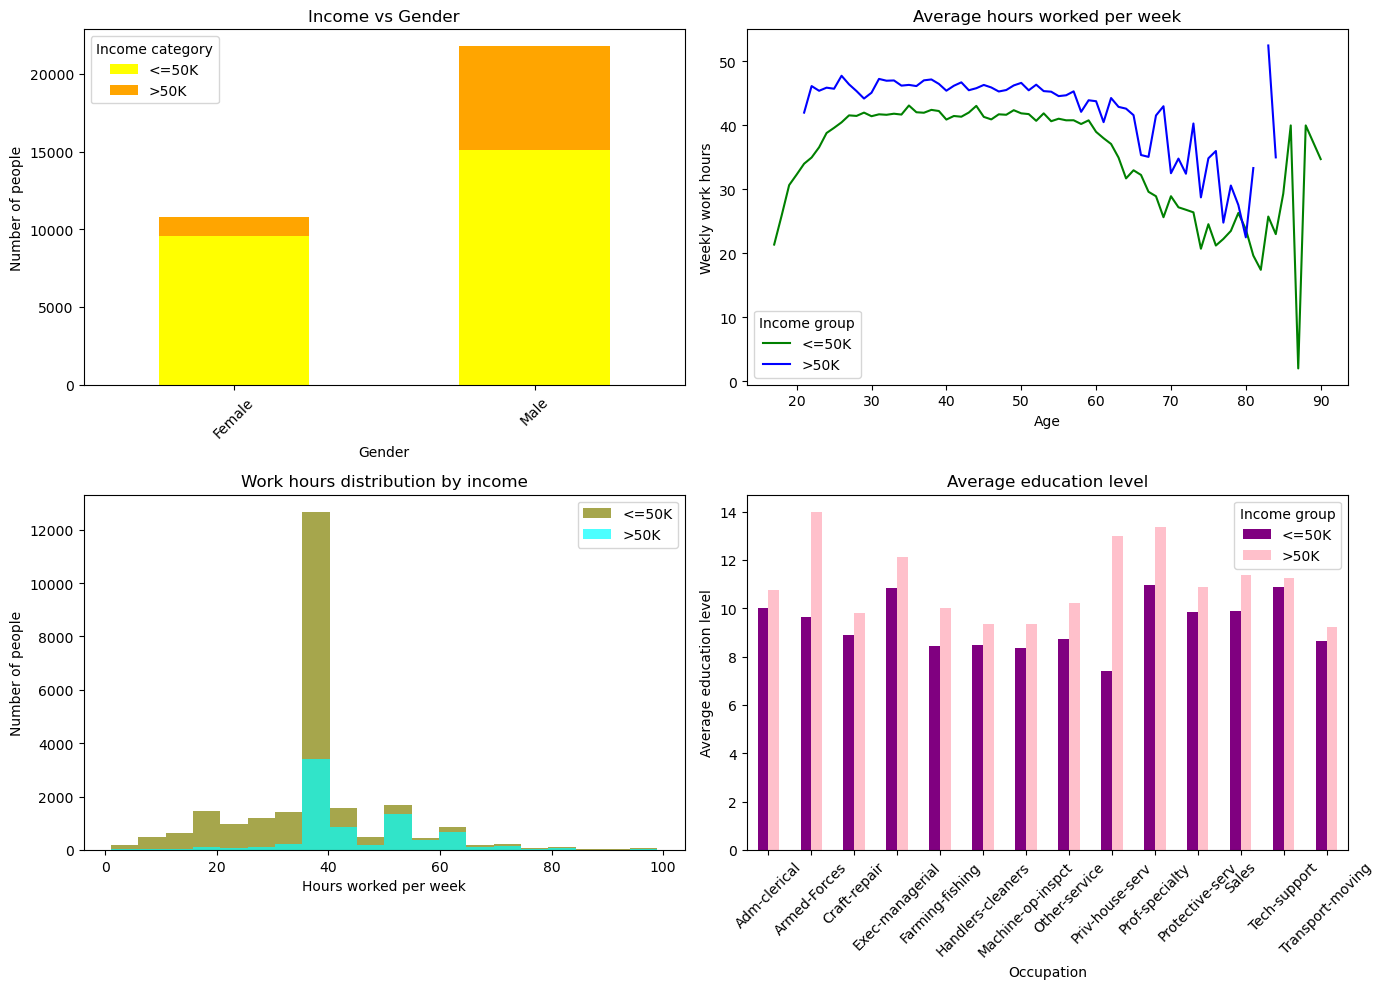

In [56]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plt.subplots_adjust(hspace=0.4, wspace=0.4)

gender_income = adults_data.groupby(['sex', 'income']).size().unstack()
gender_income.plot(kind='bar', stacked=True, ax=axes[0, 0], color=['yellow', 'orange'])
axes[0, 0].set_title('Income vs Gender')
axes[0, 0].set_xlabel('Gender')
axes[0, 0].set_ylabel('Number of people')
axes[0, 0].legend(title='Income category')
axes[0, 0].tick_params(axis='x', rotation=45)

age_hours = adults_data.groupby(['age', 'income'])['hours.per.week'].mean().unstack()
age_hours.plot(ax=axes[0, 1], color=['green', 'blue'])
axes[0, 1].set_title('Average hours worked per week')
axes[0, 1].set_xlabel('Age')
axes[0, 1].set_ylabel('Weekly work hours')
axes[0, 1].legend(title='Income group')


low_income = adults_data[adults_data['income'] == '<=50K']
high_income = adults_data[adults_data['income'] == '>50K']
axes[1, 0].hist(low_income['hours.per.week'], bins=20, alpha=0.7, label='<=50K', color='olive')
axes[1, 0].hist(high_income['hours.per.week'], bins=20, alpha=0.7, label='>50K', color='cyan')
axes[1, 0].set_title('Work hours distribution by income')
axes[1, 0].set_xlabel('Hours worked per week')
axes[1, 0].set_ylabel('Number of people')
axes[1, 0].legend()

education_occupation = adults_data.groupby(['occupation', 'income'])['education.num'].mean().unstack()
education_occupation.plot(kind='bar', ax=axes[1, 1], color=['purple', 'pink'])
axes[1, 1].set_title('Average education level')
axes[1, 1].set_xlabel('Occupation')
axes[1, 1].set_ylabel('Average education level')
axes[1, 1].legend(title='Income group')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()